In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
df = pd.read_csv("ETTh1.csv")
df.shape, df.head()

((17420, 8),
                   date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
 0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
 1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
 2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
 3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
 4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000)

In [101]:
df = df.head(24 * 55)  # 55 days of data
df.shape, df.head(5)

((1320, 8),
                   date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
 0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
 1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
 2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
 3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
 4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000)

In [102]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()
# df.head(5)

In [103]:
TOTAL_POINTS = len(df)
DAYS = 55
TRAIN_DAYS = 50
TEST_DAYS = 5
TIME = TOTAL_POINTS // DAYS
FEATURES = 7
print(f"Tensor dimensions: {DAYS} x {TIME} x {FEATURES}")

Tensor dimensions: 55 x 24 x 7


In [104]:
data = df[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', "OT"]][:DAYS*TIME].values

tensor = data.reshape(DAYS, TIME, FEATURES)
tensor.shape

(55, 24, 7)

In [105]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (50, 24, 7)
Test tensor shape: (5, 24, 7)


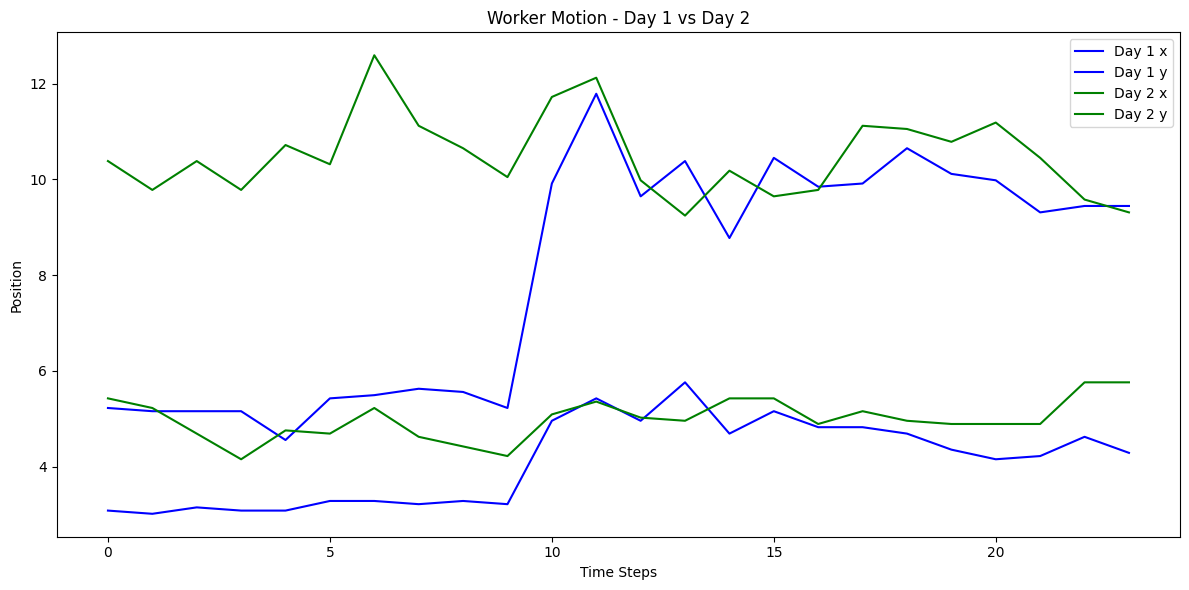

In [106]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [107]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (50, 2)
Time factors shape: (24, 2)
Feature factors shape: (7, 2)


In [108]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (50, 24, 7)
Reconstructed tensor shape: (50, 24, 7)


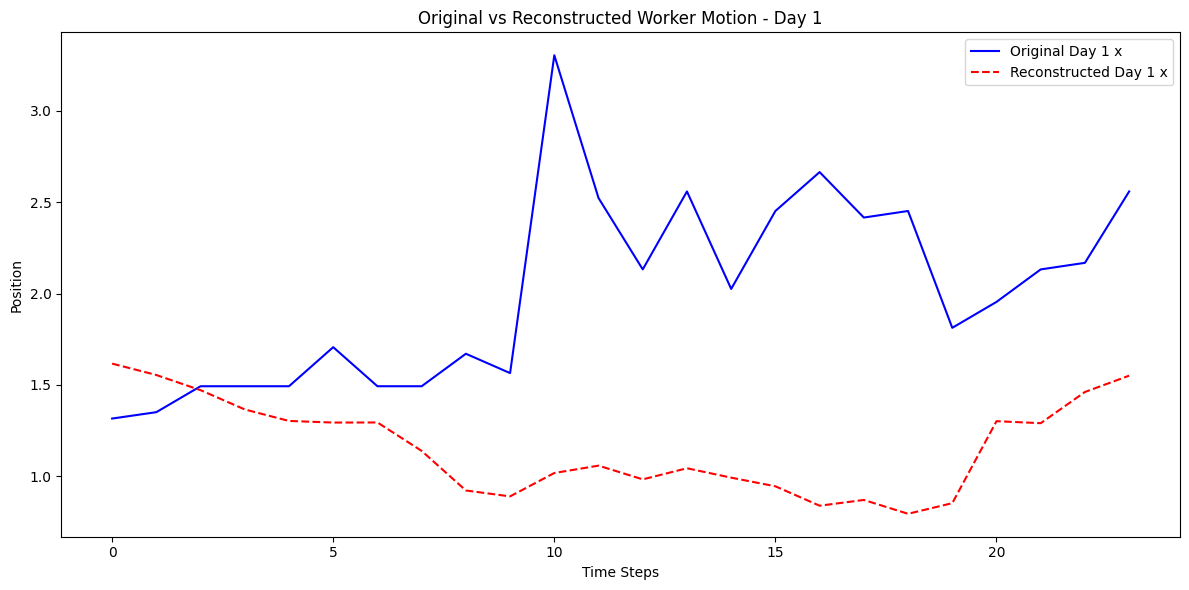

In [109]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 3], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 3], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [117]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

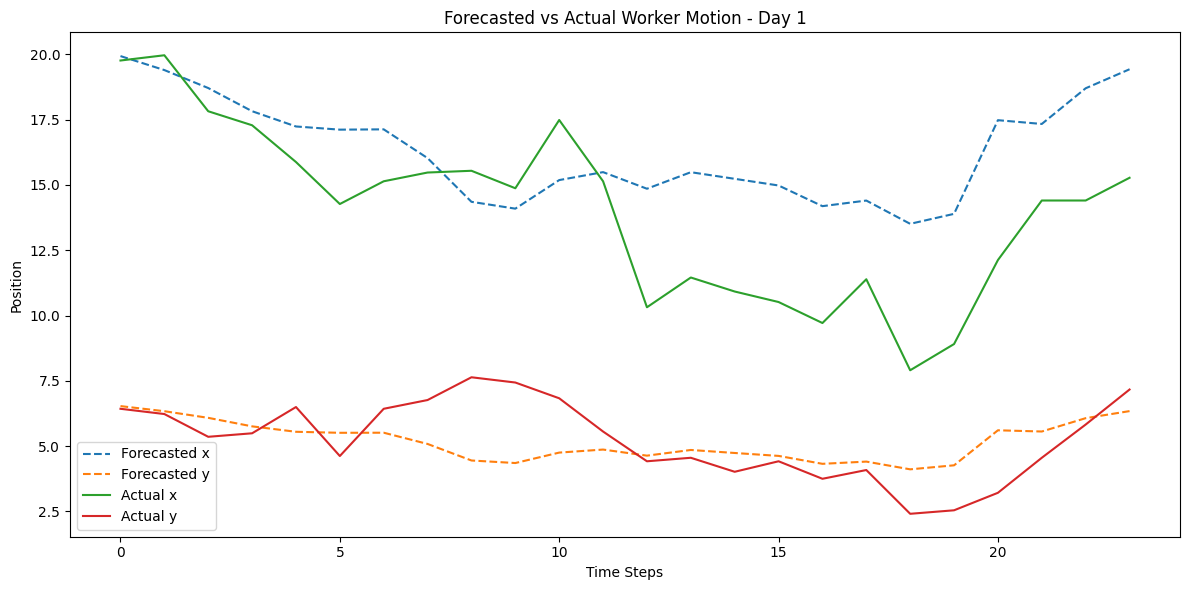

In [118]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
# # Flatten full tensor and forecast tensor into time series
# full_series = tensor.reshape(-1, FEATURES)  # (648, 4) actual for all 27 days
# forecast_series = forecast_tensor.reshape(-1, FEATURES)  # (144, 4) forecast for days 22-27

# T = DAYS * TIME
# x = np.arange(T)
# forecast_start = 21 * TIME
# x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

# plt.figure(figsize=(16, 8))

# plt.subplot(2, 1, 1)
# plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
# plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
# for d in range(1, DAYS + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('G', fontsize=12)
# plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# plt.subplot(2, 1, 2)
# plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
# plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
# for d in range(1, DAYS + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('B', fontsize=12)
# plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

Test series shape: (120, 7)
Forecast series shape: (120, 7)
x shape: (120,)


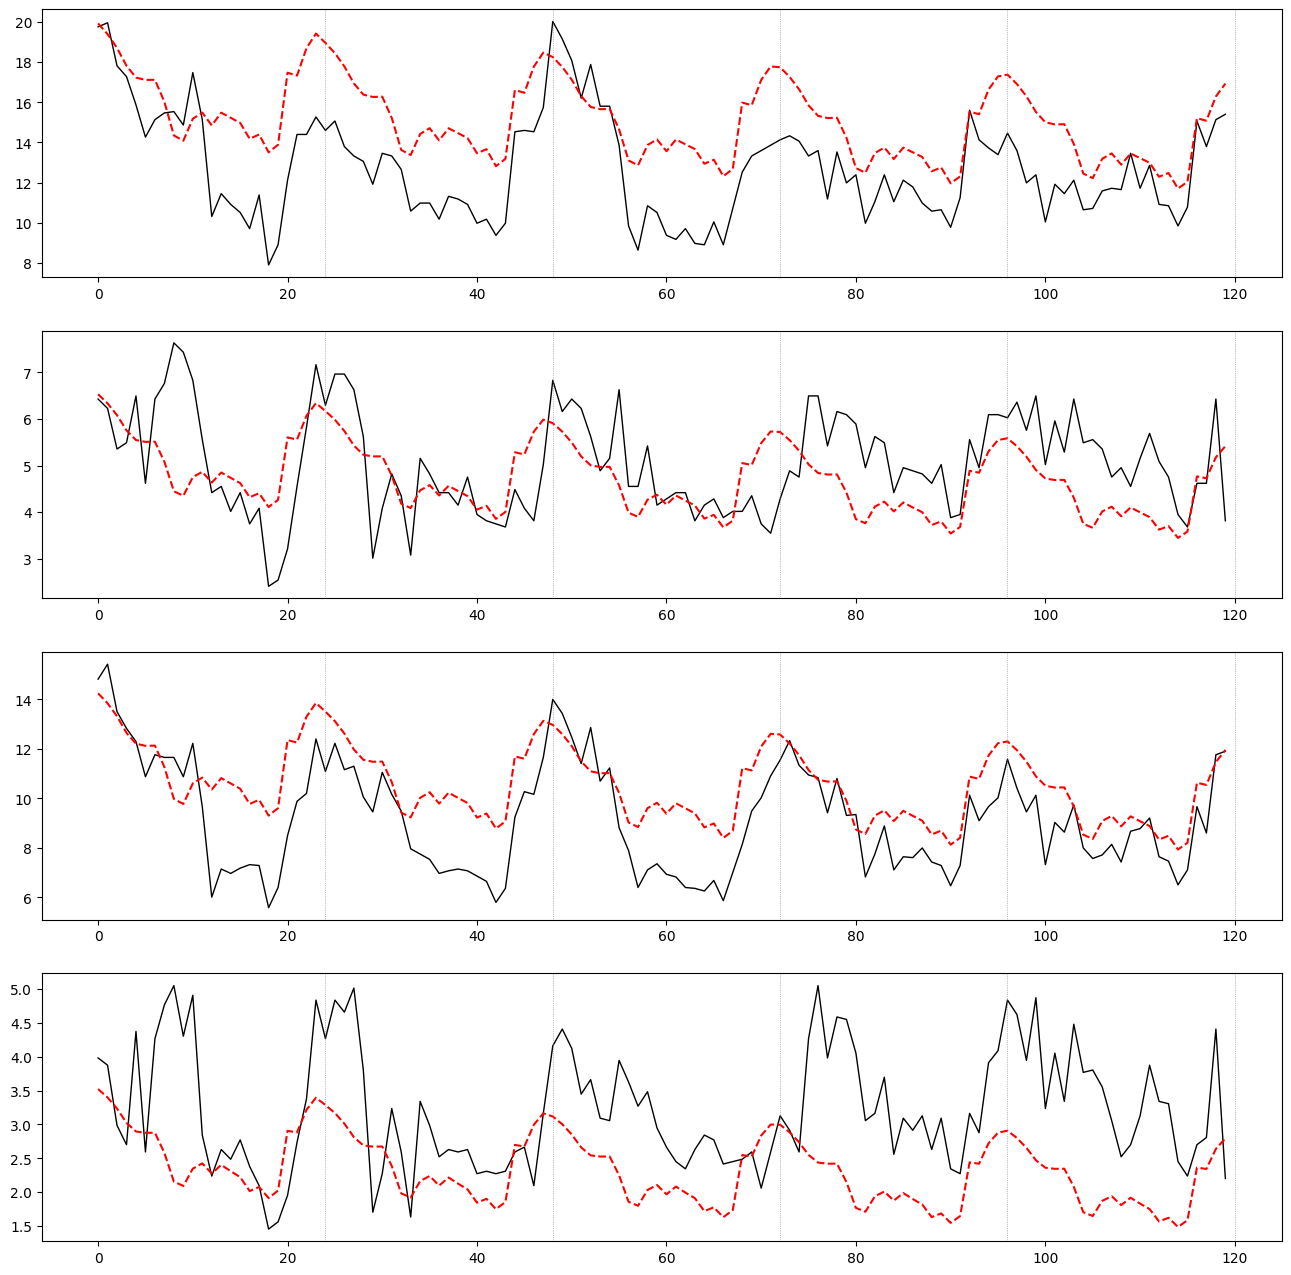

In [120]:
# Flatten full tensor and forecast tensor into time series
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)
plt.figure(figsize=(16, 16))

print(f"Test series shape: {test_series.shape}")
print(f"Forecast series shape: {forecast_series.shape}")
print(f"x shape: {x.shape}")

plt.subplot(4, 1, 1)
plt.plot(test_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 2)
plt.plot(test_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 3)
plt.plot(test_series[:, 2], 'k-', lw=1, label='Actual C')
plt.plot(forecast_series[:, 2], 'r--', lw=1.5, label='Forecast C')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 4)
plt.plot(test_series[:, 3], 'k-', lw=1, label='Actual D')
plt.plot(forecast_series[:, 3], 'r--', lw=1.5, label='Forecast D')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)


In [121]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((1200, 7), (120, 7))

In [122]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

r2_a = r2_score(test_series[:, 0], forecast_series[:, 0])
r2_b = r2_score(test_series[:, 1], forecast_series[:, 1])
r2_c = r2_score(test_series[:, 2], forecast_series[:, 2])
r2_d = r2_score(test_series[:, 3], forecast_series[:, 3])
r2_e = r2_score(test_series[:, 4], forecast_series[:, 4])
r2_f = r2_score(test_series[:, 5], forecast_series[:, 5])
r2_g = r2_score(test_series[:, 6], forecast_series[:, 6])

r2_scores = {
    'Col 1': r2_a,
    'Col 2': r2_b,
    'Col 3': r2_c,
    'Col 4': r2_d,
    'Col 5': r2_e,
    'Col 6': r2_f,
    'Col 7': r2_g
}

r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Column', 'R² Score'])
print(r2_scores_df)

  Column  R² Score
0  Col 1 -0.232565
1  Col 2 -0.028000
2  Col 3  0.256630
3  Col 4 -0.943924
4  Col 5 -1.110208
5  Col 6 -3.569637
6  Col 7 -4.844205
